In [1]:
from __future__ import annotations
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# BGVAR Sampler — Diagnostic Notebook

This notebook produces convergence diagnostics, mixing analysis, and posterior summaries for the post-burn-in samples written by `main.py`.

### Setup

In [2]:

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent           
SAMPLES_DIR  = PROJECT_ROOT / "outputs" 
OUTPUT_DIR   = PROJECT_ROOT / "outputs" 

LAG_LABELS = {0: "lag 1", 1: "lag 7"}

STATES = ["AT", "BE", "BG", "CH", "CZ", "DE", "DK", "EE", "ES","FI","FR", "GR",
          "HR", "HU", "IE", "IT", "LT", "LV", "ME", "NL", "NO", "PL", "PT",
          "RO", "RS", "SE", "SI", "SK"]
VARS_PER_STATE =  ['Price']
VAR_NAMES = [f"{s}_{v}" for s in STATES for v in VARS_PER_STATE]


def status_ess(ess_frac: float) -> str:
    """ESS efficiency thresholds — returns a status emoji."""
    if ess_frac < 0.01:
        return "🔴"
    if ess_frac < 0.05:
        return "🟡"
    return "🟢"

def status_geweke(z: float) -> str:
    """Geweke z-score thresholds."""
    az = abs(z)
    if az > 3:
        return "🔴"
    if az > 2:
        return "🟡"
    return "🟢"

def status_rhat(r: float) -> str:
    """Split R-hat thresholds."""
    if r > 1.05:
        return "🔴"
    if r > 1.01:
        return "🟡"
    return "🟢"


### Core diagnostics : ESS, Geweke, split R-hat, ACF
These are the building blocks reused throughout the notebook.

In [3]:
# ============================================================
# 1-D BUILDING BLOCKS  (operate on a single series — unchanged)
# ============================================================

def autocovariance(x: np.ndarray, max_lag: int | None = None) -> np.ndarray:
    """FFT-based autocovariance of a single 1-D series. Unchanged:
    this is a per-chain primitive and must stay 1-D."""
    x = np.asarray(x, dtype=np.float64)
    n = x.size
    if max_lag is None:
        max_lag = n - 1
    xc = x - x.mean()
    nfft = 1 << (2 * n - 1).bit_length()
    f = np.fft.fft(xc, n=nfft)
    acov = np.fft.ifft(f * np.conjugate(f)).real[:max_lag + 1] / n
    return acov


def ess_geyer(x: np.ndarray) -> float:
    """Geyer initial-monotone-sequence ESS for a SINGLE 1-D chain.
    Kept as a per-chain primitive; the multi-chain ESS is assembled
    on top of this in `ess_multichain`."""
    x = np.asarray(x, dtype=np.float64)
    n = x.size
    if n < 4 or np.var(x) == 0.0:
        return float(n)
    acov = autocovariance(x)
    rho = acov / acov[0]
    max_pairs = (n - 2) // 2
    pair_sums = rho[1:1 + 2 * max_pairs:2] + rho[2:2 + 2 * max_pairs:2]
    pos = np.where(pair_sums <= 0)[0]
    cutoff = pos[0] if pos.size else max_pairs
    pair_sums = pair_sums[:cutoff]
    for i in range(1, pair_sums.size):
        if pair_sums[i] > pair_sums[i - 1]:
            pair_sums[i] = pair_sums[i - 1]
    tau = max(1.0 + 2.0 * pair_sums.sum(), 1.0)
    return float(n / tau)


def geweke_z(x: np.ndarray, first: float = 0.1, last: float = 0.5) -> float:
    """Geweke z-score for a SINGLE 1-D chain. Unchanged: Geweke is an
    intrinsically within-chain diagnostic. With multiple chains it is
    applied once per chain (see `geweke_multichain`)."""
    n = x.size
    n_a = max(int(n * first), 2)
    n_b = max(int(n * last), 2)
    a, b = x[:n_a], x[-n_b:]
    var_a = a.var(ddof=1) * n_a / max(ess_geyer(a), 1.0)
    var_b = b.var(ddof=1) * n_b / max(ess_geyer(b), 1.0)
    se = np.sqrt(var_a / n_a + var_b / n_b)
    return 0.0 if se == 0 else float((a.mean() - b.mean()) / se)


# ============================================================
# MULTI-CHAIN DIAGNOSTICS  (input: array of shape (n_chains, n_draws))
# ============================================================

def rhat(x: np.ndarray) -> float:
    """Gelman-Rubin potential scale reduction factor (PSRF).

    Replaces the old `split_rhat`. That function faked two pseudo-chains
    by splitting one chain in half — a surrogate needed only when a
    single chain was available. With genuine independent chains we
    compute the real between-chain statistic.

    x : array of shape (n_chains, n_draws).
    """
    x = np.atleast_2d(np.asarray(x, dtype=np.float64))
    m, n = x.shape                       # m chains, n draws each
    if m < 2 or n < 4:
        return np.nan

    chain_means = x.mean(axis=1)         # (m,)
    chain_vars  = x.var(axis=1, ddof=1)  # (m,)

    B = n * chain_means.var(ddof=1)      # between-chain variance
    W = chain_vars.mean()                # within-chain variance
    if W == 0:
        return 1.0

    var_hat = (n - 1) / n * W + B / n    # marginal posterior variance estimate
    return float(np.sqrt(var_hat / W))


def ess_multichain(x: np.ndarray) -> float:
    """Combined effective sample size across chains.

    NOT the naive sum of per-chain ESS. Following Gelman et al. (BDA3),
    the per-chain autocorrelation information is pooled and then scaled
    by the marginal posterior variance `var_hat`, so that chains which
    disagree with one another are penalised rather than rewarded.

    x : array of shape (n_chains, n_draws).
    """
    x = np.atleast_2d(np.asarray(x, dtype=np.float64))
    m, n = x.shape
    if m < 2 or n < 4:
        # Fall back to the single-chain estimator.
        return ess_geyer(x.ravel())

    chain_means = x.mean(axis=1)
    chain_vars  = x.var(axis=1, ddof=1)
    B = n * chain_means.var(ddof=1)
    W = chain_vars.mean()
    if W == 0:
        return float(m * n)
    var_hat = (n - 1) / n * W + B / n

    # Average autocorrelation across chains, lag by lag.
    acov = np.array([autocovariance(x[c]) for c in range(m)])  # (m, n)
    mean_acov = acov.mean(axis=0)                              # (n,)
    rho = 1.0 - (W - mean_acov) / var_hat                      # combined autocorr.

    # Geyer initial-monotone-sequence truncation on the combined rho.
    max_pairs = (n - 2) // 2
    pair_sums = rho[1:1 + 2 * max_pairs:2] + rho[2:2 + 2 * max_pairs:2]
    pos = np.where(pair_sums <= 0)[0]
    cutoff = pos[0] if pos.size else max_pairs
    pair_sums = pair_sums[:cutoff]
    for i in range(1, pair_sums.size):
        if pair_sums[i] > pair_sums[i - 1]:
            pair_sums[i] = pair_sums[i - 1]
    tau = max(1.0 + 2.0 * pair_sums.sum(), 1.0)
    return float(m * n / tau)


def geweke_multichain(x: np.ndarray) -> np.ndarray:
    """Geweke z-score computed independently for each chain.

    Returns an array of length n_chains — there is no single combined
    Geweke statistic. The dashboard reports the worst-case |z|.

    x : array of shape (n_chains, n_draws).
    """
    x = np.atleast_2d(np.asarray(x, dtype=np.float64))
    return np.array([geweke_z(x[c]) for c in range(x.shape[0])])


# ============================================================
# SCALAR SUMMARY  (input: array of shape (n_chains, n_draws))
# ============================================================

def summarize_scalar(x: np.ndarray) -> dict:
    """Summarise one scalar quantity across all chains.

    x : array of shape (n_chains, n_draws).

    Point estimates and quantiles are computed on the POOLED draws.
    This is only meaningful once rhat is close to 1 — if rhat is large,
    the pooled median mixes chains that have not converged to the same
    target, so treat those columns with suspicion.
    """
    x = np.atleast_2d(np.asarray(x, dtype=np.float64))
    m, n = x.shape
    pooled = x.ravel()                   # (m * n,)

    ess     = ess_multichain(x)
    gw      = geweke_multichain(x)       # (m,)
    gw_max  = float(gw[np.argmax(np.abs(gw))])  # worst-case signed z

    return {
        "mean":       float(pooled.mean()),
        "median":     float(np.median(pooled)),
        "std":        float(pooled.std(ddof=1)),
        "q05":        float(np.quantile(pooled, 0.05)),
        "q95":        float(np.quantile(pooled, 0.95)),
        "ess":        ess,
        "ess_frac":   ess / pooled.size,        # denominator is now m * n
        "geweke":     gw_max,                   # worst chain
        "geweke_all": gw,                       # per-chain detail
        "rhat":       rhat(x),                  # true between-chain PSRF
        "n_chains":   m,
        "n_draws":    n,
        "n":          pooled.size,
    }


def kl_bernoulli_to_uniform(p: np.ndarray, eps: float = 1e-10) -> np.ndarray:
    """Unchanged — operates element-wise, chain structure is irrelevant."""
    p = np.clip(p, eps, 1 - eps)
    return p * np.log(2 * p) + (1 - p) * np.log(2 * (1 - p))

# Data import

In [ ]:
# Keys that must be skipped both at load time and when building
# derived scalars. Centralised here so the exclusion is explicit
# and easy to extend.
EXCLUDED_KEYS = {"mu_h", "phi_h"}


def load_all_chains(output_dir: Path, n_chains: int) -> dict[str, np.ndarray]:
    """Load every chain's samples and stack them along a new leading
    'chain' axis.

    Each per-chain array of shape (..., N_KEEP) becomes (n_chains, ..., N_KEEP).
    The constant physical-network mask is loaded once (it is identical
    across chains). Keys listed in EXCLUDED_KEYS are skipped entirely.
    """
    per_chain = []
    for c in range(n_chains):
        chain_dir = output_dir / f"chain_{c}"
        s = {}
        for f in sorted(chain_dir.glob("*_samples.npy")):
            key = f.stem.replace("_samples", "")
            # Skip explicitly excluded variables (e.g. mu_h, phi_h).
            if key in EXCLUDED_KEYS:
                continue
            s[key] = np.load(f)
        per_chain.append(s)

    # Stack each key across chains. Keys must be present in every chain.
    keys = per_chain[0].keys()
    stacked = {
        key: np.stack([per_chain[c][key] for c in range(n_chains)], axis=0)
        for key in keys
    }

    # G0_expanded is a constant mask — load once, do not stack.
    mask_path = output_dir / "chain_0" / "G0_expanded.npy"
    if mask_path.exists():
        stacked["G0_expanded"] = np.load(mask_path)

    return stacked


def companion_spectral_radius(Phi_draw: np.ndarray) -> float:
    """
    Spectral radius of the VAR companion matrix for one posterior draw.
    Phi_draw has shape (ny, ny, n_lags).
    """
    ny, _, p = Phi_draw.shape
    A = np.zeros((ny * p, ny * p))
    # First block row: [Phi_1, Phi_2, ..., Phi_p]
    for s in range(p):
        A[:ny, s * ny:(s + 1) * ny] = Phi_draw[:, :, s]
    # Identity sub-diagonal
    for s in range(p - 1):
        A[(s + 1) * ny:(s + 2) * ny, s * ny:(s + 1) * ny] = np.eye(ny)
    return float(np.max(np.abs(np.linalg.eigvals(A))))


def derived_scalars(samples: dict, compute_spectral: bool = False) -> dict[str, np.ndarray]:
    """
    Build the 1D arrays of length N_KEEP used by the dashboard.
    Spectral radius is expensive (O(N) eigendecompositions of a (ny*p)^2 matrix);
    set compute_spectral=False to skip it during development.

    """
    out = {}

    if "G0" in samples:
        out["G0_active_edges"] = samples["G0"].sum(axis=(0, 1)).astype(np.float64)

    if "G_Phi" in samples:
        # Total active arcs and per-lag breakdown
        out["G_Phi_active_arcs"] = samples["G_Phi"].sum(axis=(0, 1, 2)).astype(np.float64)
        for s, label in LAG_LABELS.items():
            if s < samples["G_Phi"].shape[2]:
                out[f"G_Phi_{label.replace(' ', '')}"] = (
                    samples["G_Phi"][:, :, s, :].sum(axis=(0, 1)).astype(np.float64)
                )

    if "G_Gamma" in samples:
        # Total active arcs and per-lag breakdown
        out["G_Gamma_active_arcs"] = samples["G_Gamma"].sum(axis=(0, 1, 2)).astype(np.float64)
        for s, label in LAG_LABELS.items():
            if s < samples["G_Gamma"].shape[2]:
                out[f"G_Gamma_{label.replace(' ', '')}"] = (
                    samples["G_Gamma"][:, :, s, :].sum(axis=(0, 1)).astype(np.float64)
                )

    if "logdet_Sigma" in samples:
        out["logdet_Sigma_u"] = samples["logdet_Sigma"].astype(np.float64)

    if "Sigma_u" in samples:
        Sig = samples["Sigma_u"]
        ny = Sig.shape[0]
        idx = np.arange(ny)
        out["total_residual_variance"] = Sig[idx, idx, :].sum(axis=0).astype(np.float64)

    if "Phi" in samples:
        Phi = samples["Phi"]
        out["Phi_total_magnitude"] = np.sqrt((Phi ** 2).sum(axis=(0, 1, 2))).astype(np.float64)
        out["Phi_largest_coeff"] = np.max(np.abs(Phi), axis=(0, 1, 2)).astype(np.float64)
        if compute_spectral:
            print("  computing Phi spectral radii (this may take a while)...")
            N = Phi.shape[-1]
            radii = np.empty(N)
            for k in range(N):
                radii[k] = companion_spectral_radius(Phi[:, :, :, k])
                if (k + 1) % 1000 == 0:
                    print(f"    {k + 1}/{N}")
            out["var_stability_Phi"] = radii

    if "Gamma" in samples:
        Gamma = samples["Gamma"]
        n_wind = 28

        gamma_wind = Gamma[:, :n_wind, :, :]
        gamma_solar = Gamma[:, n_wind:, :, :]

        out["Gamma_wind_total_magnitude"] = np.sqrt((gamma_wind ** 2).sum(axis=(0, 1, 2))).astype(np.float64)
        out["Gamma_solar_total_magnitude"] = np.sqrt((gamma_solar ** 2).sum(axis=(0, 1, 2))).astype(np.float64)

        if "G_Gamma" in samples:
            G = samples["G_Gamma"]
            G_wind = G[:, :n_wind, :, :]
            G_solar = G[:, n_wind:, :, :]

            out["G_Gamma_wind_active"] = G_wind.sum(axis=(0, 1, 2)).astype(np.float64)
            out["G_Gamma_solar_active"] = G_solar.sum(axis=(0, 1, 2)).astype(np.float64)

        out["Gamma_wind_max"] = np.max(np.abs(gamma_wind), axis=(0, 1, 2)).astype(np.float64)
        out["Gamma_solar_max"] = np.max(np.abs(gamma_solar), axis=(0, 1, 2)).astype(np.float64)

    # Stochastic-volatility parameters: mu_h and phi_h are explicitly
    # excluded; only sigma_h2 is forwarded as-is.
    for key in ("sigma_h2",):
        if key in samples and key not in EXCLUDED_KEYS:
            out[key] = samples[key].astype(np.float64)

    if "h" in samples:
        out["mean_h_t"] = samples["h"].mean(axis=0).astype(np.float64)

    return out


def derived_scalars_multichain(stacked: dict, n_chains: int,
                               compute_spectral: bool = False) -> dict[str, np.ndarray]:
    """Apply the existing per-chain `derived_scalars` to each chain
    separately, then stack the results into (n_chains, N_KEEP) arrays.

    This reuses `derived_scalars` unchanged instead of rewriting every
    axis index inside it.
    """
    per_chain_out = []
    for c in range(n_chains):
        # Rebuild a single-chain `samples` dict by slicing off chain c.
        single = {}
        for key, arr in stacked.items():
            if key == "G0_expanded":          # constant mask, not stacked
                single[key] = arr
            else:
                single[key] = arr[c]          # drop the leading chain axis
        per_chain_out.append(derived_scalars(single, compute_spectral=compute_spectral))

    # Stack each derived quantity across chains.
    keys = per_chain_out[0].keys()
    return {
        key: np.stack([per_chain_out[c][key] for c in range(n_chains)], axis=0)
        for key in keys
    }


N_CHAINS = 4

print("Loading all chains...")
stacked = load_all_chains(OUTPUT_DIR, N_CHAINS)
for k, v in stacked.items():
    print(f"  {k:<20} shape={v.shape}  dtype={v.dtype}")

print("\nBuilding derived scalars per chain, then stacking...")
scalars = derived_scalars_multichain(stacked, N_CHAINS, compute_spectral=True)
# each scalars[name] now has shape (N_CHAINS, N_KEEP)

N_KEEP = next(iter(scalars.values())).shape[1]
print(f"\nN_CHAINS = {N_CHAINS}, N_KEEP = {N_KEEP}")

Loading all chains...
  G0                   shape=(4, 28, 28, 5000)  dtype=uint8
  G_Gamma              shape=(4, 28, 53, 2, 5000)  dtype=uint8
  G_Phi                shape=(4, 28, 28, 2, 5000)  dtype=uint8
  gamma_norm           shape=(4, 5000)  dtype=float64
  Gamma                shape=(4, 28, 53, 2, 5000)  dtype=float64
  h                    shape=(4, 358, 5000)  dtype=float32
  lambda_t             shape=(4, 358, 5000)  dtype=float32
  logdet_Sigma         shape=(4, 5000)  dtype=float32
  phi_norm             shape=(4, 5000)  dtype=float64
  Phi                  shape=(4, 28, 28, 2, 5000)  dtype=float32
  sigma_h2             shape=(4, 5000)  dtype=float32
  Sigma_u              shape=(4, 28, 28, 5000)  dtype=float32
  G0_expanded          shape=(28, 28)  dtype=uint8

Building derived scalars per chain, then stacking...
  computing Phi spectral radii (this may take a while)...
    1000/5000
    2000/5000
    3000/5000
    4000/5000
    5000/5000
  computing Phi spectral radii (t

## Global Health Check
If everything is green, the chain is healthy and you can move to interpretation. 
If anything is yellow or red, drill down into the relevant block-specific cell.

In [5]:
def build_dashboard(scalars: dict[str, np.ndarray]) -> pd.DataFrame:
    """scalars[name] has shape (n_chains, n_draws)."""
    rows = []
    for name, x in scalars.items():
        s = summarize_scalar(x)
        rows.append({
            "Quantity":    name,
            "Median":      f"{s['median']:.4f}",      # pooled
            "Mean":        f"{s['mean']:.4f}",        # pooled
            "90% CI":      f"[{s['q05']:.3f}, {s['q95']:.3f}]",
            "ESS":         f"{s['ess']:.0f}",         # combined across chains
            "ESS/N (%)":   f"{100 * s['ess_frac']:.1f}",  # N = n_chains * n_draws
            "Geweke z":    f"{s['geweke']:+.2f}",     # worst chain
            "R̂":           f"{s['rhat']:.3f}",        # true between-chain PSRF
            "Status":      f"{status_ess(s['ess_frac'])} "
                           f"{status_geweke(s['geweke'])} "
                           f"{status_rhat(s['rhat'])}",
        })
    return pd.DataFrame(rows).set_index("Quantity")

dashboard = build_dashboard(scalars)
dashboard

,Median,Mean,90% CI,ESS,ESS/N (%),Geweke z,R̂,Status
Quantity,,,,,,,,
G0_active_edges,40.0000,40.2242,"[39.000, 41.000]",1761,8.8,+1.27,1.000,🟢 🟢 🟢
G_Phi_active_arcs,833.0000,833.5430,"[806.000, 861.000]",108,0.5,+1.84,1.018,🔴 🟢 🟡
G_Phi_lag1,396.0000,395.9575,"[375.000, 418.000]",49,0.2,+3.28,1.050,🔴 🔴 🟡
G_Phi_lag7,437.0000,437.5854,"[419.000, 458.000]",97,0.5,+2.07,1.019,🔴 🟡 🟡
G_Gamma_active_arcs,1606.0000,1606.8835,"[1569.000, 1646.000]",127,0.6,-2.09,1.002,🔴 🟡 🟢
G_Gamma_lag1,816.0000,815.8005,"[788.000, 843.000]",59,0.3,-3.33,1.017,🔴 🔴 🟡
G_Gamma_lag7,791.0000,791.0829,"[764.000, 819.000]",130,0.6,+2.59,1.005,🔴 🟡 🟢
logdet_Sigma_u,-111.2550,-111.2530,"[-113.188, -109.339]",339,1.7,+3.18,1.002,🟡 🔴 🟢
tr_Sigma_u,2.0643,2.0685,"[1.867, 2.280]",453,2.3,+3.13,1.001,🟡 🔴 🟢


## Convergence health check: trace plot and running means

In [6]:
def pool_chains(arr: np.ndarray) -> np.ndarray:
    """Concatenate the per-chain draws into a single posterior sample.

    Input  : (n_chains, ..., N_KEEP)   — leading chain axis, trailing draw axis
    Output : (..., n_chains * N_KEEP)  — one combined sample dimension

    Use ONLY after R-hat confirms the chains agree. Pooling
    non-converged chains mixes different targets.
    """
    # Move the chain axis next to the draw axis, then merge the two.
    a = np.moveaxis(arr, 0, -2)                 # (..., n_chains, N_KEEP)
    return a.reshape(*a.shape[:-2], -1)         # (..., n_chains * N_KEEP)


# --- Coefficienti Phi: (n_chains, ny, ny, n_lags, N_KEEP) ---
Phi_pool = pool_chains(stacked["Phi"])          # (ny, ny, n_lags, 4*N_KEEP)
Phi_hat  = Phi_pool.mean(axis=-1)               # stima puntuale
Phi_lo   = np.quantile(Phi_pool, 0.05, axis=-1) # banda di credibilità
Phi_hi   = np.quantile(Phi_pool, 0.95, axis=-1)

# --- PIP / MPM su G0 ---
G0_pool = pool_chains(stacked["G0"])            # (ny, ny, 4*N_KEEP)
pip_G0  = G0_pool.mean(axis=-1)                 # posterior inclusion prob.
mpm_G0  = (pip_G0 >= 0.5)                       # median probability model

# --- Posterior path di h_t ---
h_pool   = pool_chains(stacked["h"])            # (T_eff, 4*N_KEEP)
h_median = np.median(h_pool, axis=-1)
h_lo     = np.quantile(h_pool, 0.05, axis=-1)
h_hi     = np.quantile(h_pool, 0.95, axis=-1)

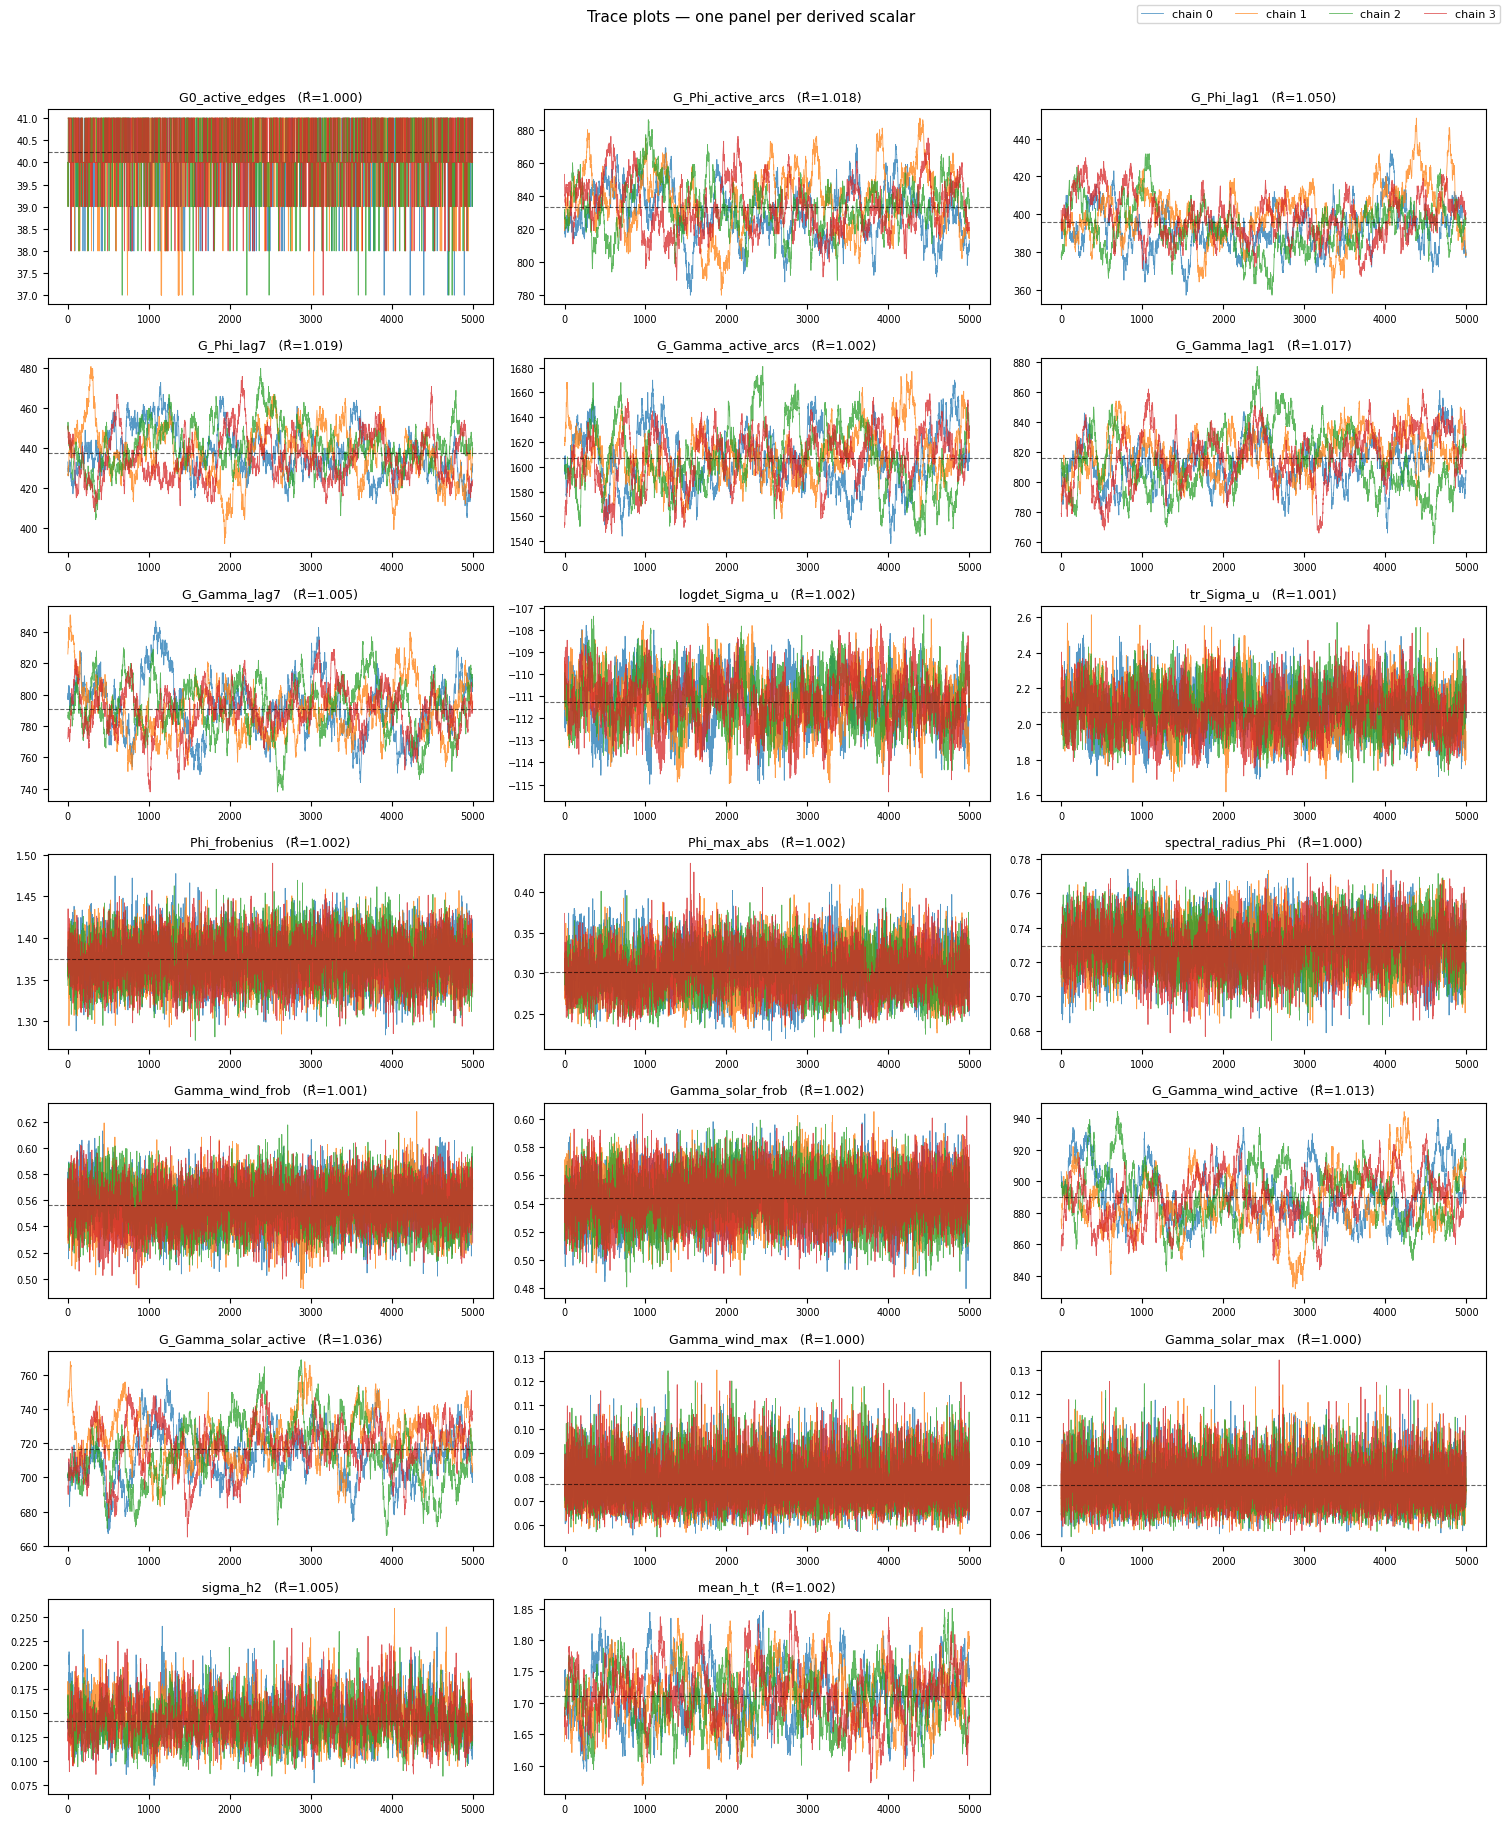

In [7]:
def trace_plot_grid(scalars: dict[str, np.ndarray],
                    n_cols: int = 3,
                    thin: int = 1,
                    figsize_per_row: float = 2.6):
    """Trace plot grid: one subplot per derived scalar, one line per chain.

    scalars[name] has shape (n_chains, n_draws) — the output of
    `derived_scalars_multichain`.

    thin : plot every `thin`-th draw to keep the figure light when
           n_draws is large (e.g. thin=5 for 10000+ draws). Diagnostics
           are still computed on the full series.
    """
    names = list(scalars.keys())
    n = len(names)
    n_rows = (n + n_cols - 1) // n_cols

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(5.0 * n_cols, figsize_per_row * n_rows),
        squeeze=False,
    )

    for idx, name in enumerate(names):
        ax = axes[idx // n_cols][idx % n_cols]
        x = np.atleast_2d(scalars[name])      # (n_chains, n_draws)
        m, n_draws = x.shape
        it = np.arange(0, n_draws, thin)

        for c in range(m):
            ax.plot(it, x[c, ::thin], lw=0.6, alpha=0.75, label=f"chain {c}")

        # Pooled mean as a reference line.
        pooled_mean = x.mean()
        ax.axhline(pooled_mean, color="black", lw=0.8, ls="--", alpha=0.6)

        # R-hat in the title ties the plot to the dashboard.
        r = rhat(x)
        flag = "" if (np.isnan(r) or r < 1.1) else "  ⚠"
        ax.set_title(f"{name}   (R̂={r:.3f}){flag}", fontsize=9)
        ax.tick_params(labelsize=7)

    # Blank out any unused cells in the last row.
    for idx in range(n, n_rows * n_cols):
        axes[idx // n_cols][idx % n_cols].axis("off")

    # One shared legend instead of 20 identical ones.
    handles, labels = axes[0][0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", fontsize=8, ncol=N_CHAINS)

    fig.suptitle("Trace plots — one panel per derived scalar", fontsize=11, y=1.0)
    fig.tight_layout(rect=[0, 0, 1, 0.98])
    return fig


fig = trace_plot_grid(scalars, n_cols=3, thin=1)
plt.show()

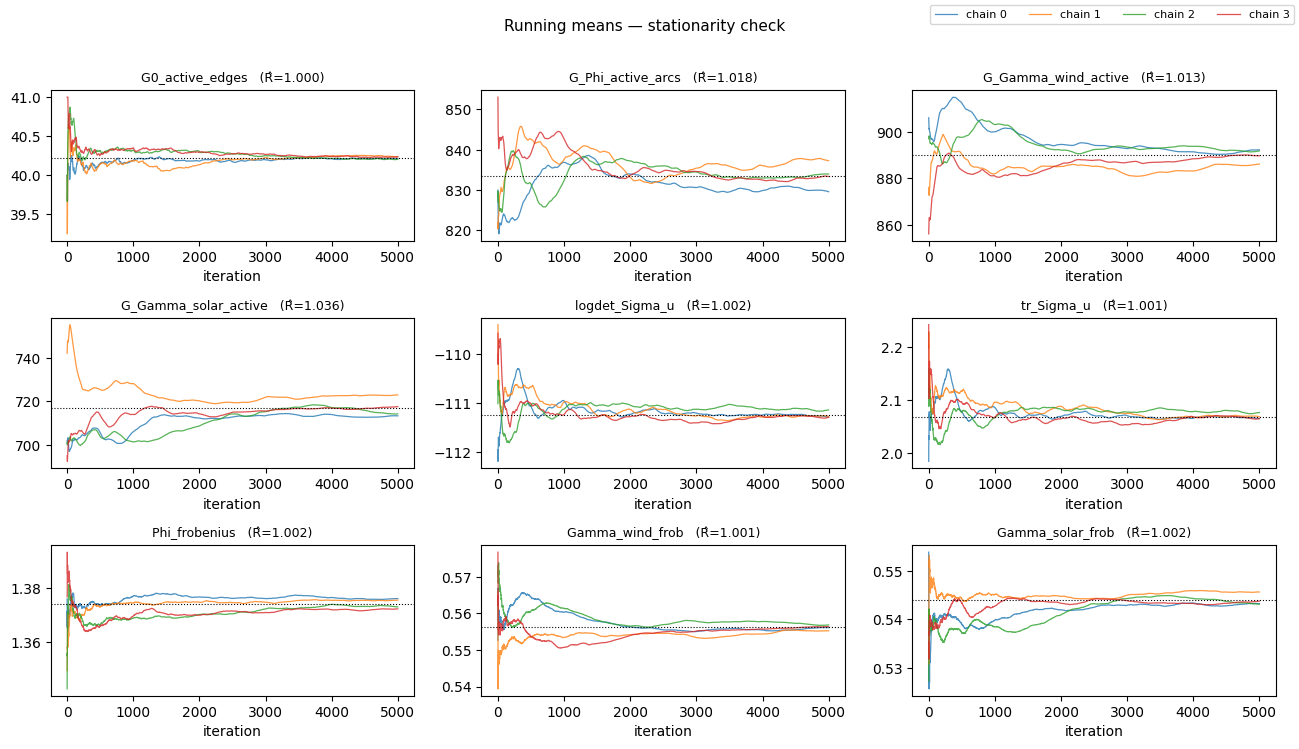

In [8]:
def plot_running_means(scalars: dict[str, np.ndarray],
                       keys: list[str],
                       title: str,
                       out_path: Path | None = None) -> None:
    """Running-mean convergence check.

    scalars[key] has shape (n_chains, N_KEEP). One subplot per quantity,
    one running-mean line PER CHAIN. Chains kept separate on purpose:
    the diagnostic is whether the four running means converge to the
    same level.
    """
    n_q = len(keys)
    n_cols = 3
    n_rows = int(np.ceil(n_q / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 2.5 * n_rows),
                             squeeze=False)

    for k, key in enumerate(keys):
        ax = axes[k // n_cols, k % n_cols]
        x = np.atleast_2d(scalars[key])          # (n_chains, N_KEEP)
        m, n_draws = x.shape
        it = np.arange(1, n_draws + 1)

        # One running mean per chain.
        for c in range(m):
            running = np.cumsum(x[c]) / it
            ax.plot(running, lw=0.9, alpha=0.8, label=f"chain {c}")

        # Pooled mean across all chains as reference.
        ax.axhline(x.mean(), color="black", ls=":", lw=0.8)

        # R-hat in the title ties the panel to the dashboard.
        r = rhat(x)
        flag = "" if (np.isnan(r) or r < 1.1) else "  ⚠"
        ax.set_title(f"{key}   (R̂={r:.3f}){flag}", fontsize=9)
        ax.set_xlabel("iteration")

    for k in range(n_q, n_rows * n_cols):
        axes[k // n_cols, k % n_cols].axis("off")

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", fontsize=8, ncol=N_CHAINS)
    fig.suptitle(title, fontsize=11)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    if out_path:
        fig.savefig(out_path, dpi=120)
    plt.show()

# Pick the most important quantities for the health check
DASHBOARD_KEYS = [
    "G0_active_edges", "G_Phi_active_arcs",
     "G_Gamma_wind_active",  "G_Gamma_solar_active",
    "logdet_Sigma_u", "tr_Sigma_u",
    "Phi_frobenius", "spectral_radius",
    "Gamma_wind_frob", "Gamma_solar_frob", 
   
]
DASHBOARD_KEYS = [k for k in DASHBOARD_KEYS if k in scalars]

plot_running_means(scalars, DASHBOARD_KEYS,
                   "Running means — stationarity check")

## Block diagnostics of $G_0$ (contemporaneous graph)

G_0 — non-degenerate arcs: 76
      median ESS:          3615
      arcs below ESS=100:  0 (0.0%)
      arcs with R-hat>1.1: 0 (0.0%)
      degenerate arcs:     680


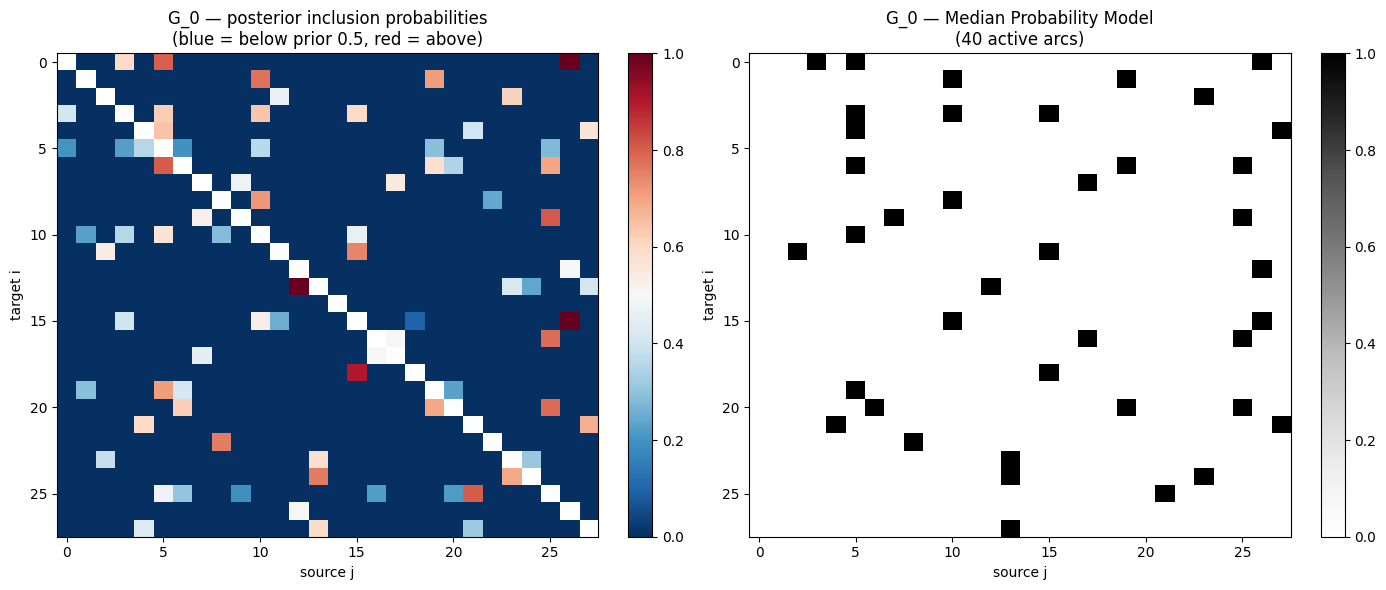

      mean KL(post || prior 0.5) over arcs: 0.6323
        (≈ 0 means uninformative; > 0.05 means strong departure)


In [9]:
if "G0" in stacked:
    G0 = stacked["G0"]                       # (n_chains, ny, ny, N_KEEP)
    n_chains, ny, _, N_KEEP = G0.shape
    G0_pool = pool_chains(G0)                # (ny, ny, n_chains * N_KEEP)
    N_tot = G0_pool.shape[-1]

    # Per-arc inclusion probabilities — pooled over chains AND draws.
    edge_prob_G0 = G0_pool.mean(axis=2)      # (ny, ny)
    np.fill_diagonal(edge_prob_G0, np.nan)

    # Per-arc ESS on the POOLED chain (true effective sample size).
    ess_per_arc = np.empty((ny, ny))
    for i in range(ny):
        for j in range(ny):
            if i == j:
                ess_per_arc[i, j] = np.nan
            else:
                ess_per_arc[i, j] = ess_multichain(G0[:, i, j, :].astype(np.float64))

    # Per-arc R-hat — convergence of the edge indicator across chains.
    rhat_per_arc = np.empty((ny, ny))
    for i in range(ny):
        for j in range(ny):
            rhat_per_arc[i, j] = (np.nan if i == j
                                  else rhat(G0[:, i, j, :].astype(np.float64)))

    # Degenerate arcs: variance zero across the pooled sample.
    arc_var = G0_pool.var(axis=2)
    np.fill_diagonal(arc_var, np.nan)
    degenerate_mask = (arc_var == 0)
    n_degenerate = int(np.nansum(degenerate_mask))

    ess_live = ess_per_arc[~degenerate_mask & ~np.isnan(ess_per_arc)]
    rhat_live = rhat_per_arc[~degenerate_mask & ~np.isnan(rhat_per_arc)]
    print(f"G_0 — non-degenerate arcs: {ess_live.size}")
    print(f"      median ESS:          {np.median(ess_live):.0f}")
    print(f"      arcs below ESS=100:  {(ess_live < 100).sum()} "
          f"({100*(ess_live < 100).mean():.1f}%)")
    print(f"      arcs with R-hat>1.1: {(rhat_live > 1.1).sum()} "
          f"({100*(rhat_live > 1.1).mean():.1f}%)")
    print(f"      degenerate arcs:     {n_degenerate}")

    # --- Heatmaps: identical to before, computed on the pooled PIP ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    im0 = axes[0].imshow(edge_prob_G0, cmap="RdBu_r", vmin=0, vmax=1, aspect="auto")
    axes[0].set_title("G_0 — posterior inclusion probabilities\n"
                      "(blue = below prior 0.5, red = above)")
    axes[0].set_xlabel("source j")
    axes[0].set_ylabel("target i")
    plt.colorbar(im0, ax=axes[0], fraction=0.046)

    G0_mpm = (edge_prob_G0 > 0.5).astype(np.float32)
    n_mpm = int(np.nansum(G0_mpm))
    im1 = axes[1].imshow(G0_mpm, cmap="Greys", vmin=0, vmax=1, aspect="auto")
    axes[1].set_title(f"G_0 — Median Probability Model\n({n_mpm} active arcs)")
    axes[1].set_xlabel("source j")
    axes[1].set_ylabel("target i")
    plt.colorbar(im1, ax=axes[1], fraction=0.046)
    fig.tight_layout()
    plt.show()

    kl_G0 = kl_bernoulli_to_uniform(edge_prob_G0)
    print(f"      mean KL(post || prior 0.5) over arcs: {np.nanmean(kl_G0):.4f}")
    print(f"        (≈ 0 means uninformative; > 0.05 means strong departure)")
else:
    print("G0 not in stacked.")

## Block diagnostics of $G_Φ$ and $G_\Gamma$ (temporal graph, per lag)

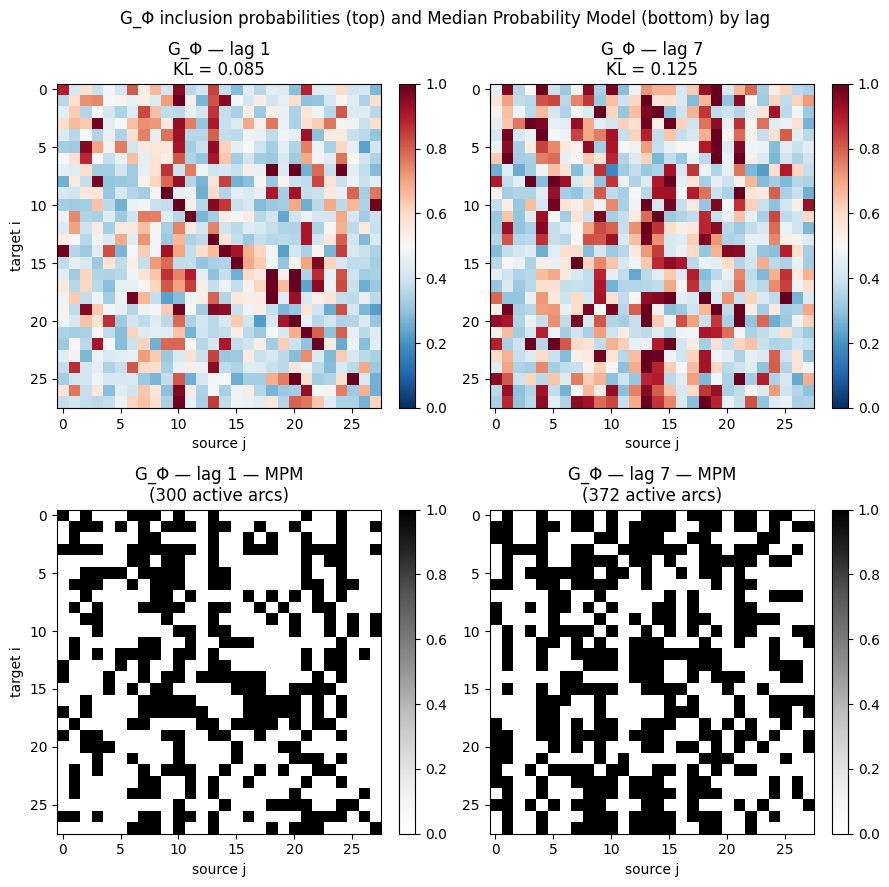

  Lag  Live arcs  Degenerate arcs Median ESS Frac < 100 R-hat > 1.1 Mean KL  MPM arcs
lag 1        772               12         82      73.2%        1.7%  0.0851       300
lag 7        763               21         80      76.0%        2.1%  0.1252       372


In [10]:
if "G_Phi" in stacked:
    G_Phi = stacked["G_Phi"]                      # (n_chains, ny, ny, p, N_KEEP)
    n_chains, ny, _, p, N_KEEP = G_Phi.shape
    G_Phi_pool = pool_chains(G_Phi)               # (ny, ny, p, n_chains * N_KEEP)
    N_tot = G_Phi_pool.shape[-1]

    edge_prob_GPhi = G_Phi_pool.mean(axis=3)      # (ny, ny, p) — pooled

    fig, axes = plt.subplots(2, p, figsize=(4.5 * p, 9))
    if p == 1:
        axes = axes.reshape(2, 1)

    kl_table = []
    for s in range(p):
        ax_top = axes[0, s]
        e = edge_prob_GPhi[:, :, s]
        im_top = ax_top.imshow(e, cmap="RdBu_r", vmin=0, vmax=1, aspect="auto")
        kl = float(np.mean(kl_bernoulli_to_uniform(e)))
        kl_table.append({"Lag": LAG_LABELS.get(s, f"lag {s+1}"),
                         "Mean KL(post||0.5)": f"{kl:.4f}",
                         "MPM active arcs": int((e > 0.5).sum())})
        ax_top.set_title(f"G_Φ — {LAG_LABELS.get(s, f'lag {s+1}')}\nKL = {kl:.3f}")
        ax_top.set_xlabel("source j")
        if s == 0:
            ax_top.set_ylabel("target i")
        plt.colorbar(im_top, ax=ax_top, fraction=0.046)

        ax_bot = axes[1, s]
        GPhi_mpm = (e > 0.5).astype(np.float32)
        n_mpm = int(np.nansum(GPhi_mpm))
        im_bot = ax_bot.imshow(GPhi_mpm, cmap="Greys", vmin=0, vmax=1, aspect="auto")
        ax_bot.set_title(f"G_Φ — {LAG_LABELS.get(s, f'lag {s+1}')} — MPM\n"
                         f"({n_mpm} active arcs)")
        ax_bot.set_xlabel("source j")
        if s == 0:
            ax_bot.set_ylabel("target i")
        plt.colorbar(im_bot, ax=ax_bot, fraction=0.046)

    fig.suptitle("G_Φ inclusion probabilities (top) and Median Probability Model (bottom) by lag",
                 fontsize=12)
    fig.tight_layout()
    plt.show()

    # Per-lag ESS summary — ESS computed on the POOLED chain per arc.
    rows = []
    for s in range(p):
        slab = G_Phi[:, :, :, s, :].astype(np.float64)    # (n_chains, ny, ny, N_KEEP)
        # Flatten the (ny, ny) arc grid, keep chain and draw axes.
        flat = slab.reshape(n_chains, -1, N_KEEP)         # (n_chains, ny*ny, N_KEEP)
        flat_pool = pool_chains(flat)                     # (ny*ny, n_chains*N_KEEP)
        var = flat_pool.var(axis=1)
        live_mask = var > 0
        live_idx = np.where(live_mask)[0]
        ess_live = np.array([ess_multichain(flat[:, k, :]) for k in live_idx])
        rhat_live = np.array([rhat(flat[:, k, :]) for k in live_idx])
        rows.append({
            "Lag":             LAG_LABELS.get(s, f"lag {s+1}"),
            "Live arcs":       int(live_mask.sum()),
            "Degenerate arcs": int((~live_mask).sum()),
            "Median ESS":      f"{np.median(ess_live):.0f}",
            "Frac < 100":      f"{(ess_live < 100).mean():.1%}",
            "R-hat > 1.1":     f"{(rhat_live > 1.1).mean():.1%}",
            "Mean KL":         kl_table[s]["Mean KL(post||0.5)"],
            "MPM arcs":        kl_table[s]["MPM active arcs"],
        })
    print(pd.DataFrame(rows).to_string(index=False))
else:
    print("G_Phi not in stacked.")

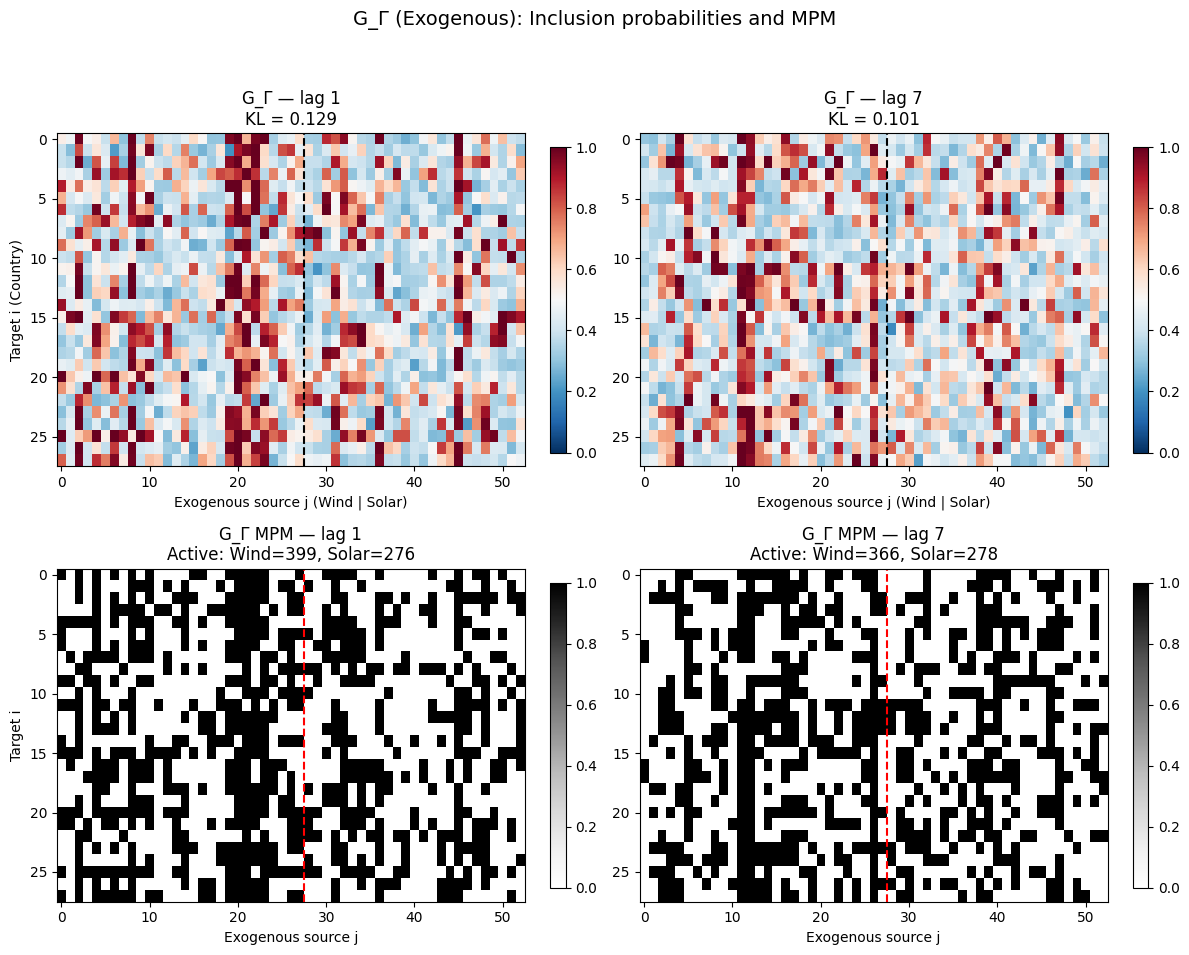


--- G_Gamma Efficiency and Selection Summary ---
  Lag  Live arcs  Wind MPM  Solar MPM Median ESS ESS < 100 R-hat > 1.1 Mean KL
lag 1       1431       399        276         83     72.2%        1.6%  0.1287
lag 7       1459       366        278         83     75.5%        1.2%  0.1015


In [11]:
if "G_Gamma" in stacked:
    G_Gamma = stacked["G_Gamma"]                  # (n_chains, ny, nx, p, N_KEEP)
    n_chains, ny, nx, p, N_KEEP = G_Gamma.shape
    n_wind = 28
    G_Gamma_pool = pool_chains(G_Gamma)           # (ny, nx, p, n_chains * N_KEEP)

    edge_prob_GGamma = G_Gamma_pool.mean(axis=3)  # (ny, nx, p) — pooled

    fig, axes = plt.subplots(2, p, figsize=(6 * p, 10))
    if p == 1:
        axes = axes.reshape(2, 1)

    kl_table = []                                 # <-- populated in this loop
    for s in range(p):
        # ----- Top row: posterior inclusion probabilities -----
        ax_top = axes[0, s]
        e = edge_prob_GGamma[:, :, s]             # pooled PIP for this lag
        im_top = ax_top.imshow(e, cmap="RdBu_r", vmin=0, vmax=1, aspect="auto")
        ax_top.axvline(x=n_wind - 0.5, color="black", linestyle="--", lw=1.5)

        kl = float(np.mean(kl_bernoulli_to_uniform(e)))
        kl_table.append({
            "Lag":       LAG_LABELS.get(s, f"lag {s+1}"),
            "Mean KL":   f"{kl:.4f}",
            "MPM Wind":  int((e[:, :n_wind] > 0.5).sum()),
            "MPM Solar": int((e[:, n_wind:] > 0.5).sum()),
        })

        ax_top.set_title(f"G_Γ — {LAG_LABELS.get(s, f'lag {s+1}')}\nKL = {kl:.3f}")
        ax_top.set_xlabel("Exogenous source j (Wind | Solar)")
        if s == 0:
            ax_top.set_ylabel("Target i (Country)")
        plt.colorbar(im_top, ax=ax_top, fraction=0.03)

        # ----- Bottom row: Median Probability Model -----
        ax_bot = axes[1, s]
        GGamma_mpm = (e > 0.5).astype(np.float32)
        im_bot = ax_bot.imshow(GGamma_mpm, cmap="Greys", vmin=0, vmax=1, aspect="auto")
        ax_bot.axvline(x=n_wind - 0.5, color="red", linestyle="--", lw=1.5)

        n_wind_act  = kl_table[s]["MPM Wind"]
        n_solar_act = kl_table[s]["MPM Solar"]
        ax_bot.set_title(f"G_Γ MPM — {LAG_LABELS.get(s, f'lag {s+1}')}\n"
                         f"Active: Wind={n_wind_act}, Solar={n_solar_act}")
        ax_bot.set_xlabel("Exogenous source j")
        if s == 0:
            ax_bot.set_ylabel("Target i")
        plt.colorbar(im_bot, ax=ax_bot, fraction=0.03)

    fig.suptitle("G_Γ (Exogenous): Inclusion probabilities and MPM", fontsize=14)
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # ----- Summary table — ESS / R-hat on the pooled chain per arc -----
    rows = []
    for s in range(p):
        slab = G_Gamma[:, :, :, s, :].astype(np.float64)   # (n_chains, ny, nx, N_KEEP)
        flat = slab.reshape(n_chains, -1, N_KEEP)          # (n_chains, ny*nx, N_KEEP)
        flat_pool = pool_chains(flat)
        var = flat_pool.var(axis=1)
        live_mask = var > 0
        if live_mask.any():
            live_idx = np.where(live_mask)[0]
            ess_live  = np.array([ess_multichain(flat[:, k, :]) for k in live_idx])
            rhat_live = np.array([rhat(flat[:, k, :])           for k in live_idx])
            med_ess   = f"{np.median(ess_live):.0f}"
            frac_low  = f"{(ess_live < 100).mean():.1%}"
            frac_rhat = f"{(rhat_live > 1.1).mean():.1%}"
        else:
            med_ess, frac_low, frac_rhat = "N/A", "0%", "0%"
        rows.append({
            "Lag":         LAG_LABELS.get(s, f"lag {s+1}"),
            "Live arcs":   int(live_mask.sum()),
            "Wind MPM":    kl_table[s]["MPM Wind"],
            "Solar MPM":   kl_table[s]["MPM Solar"],
            "Median ESS":  med_ess,
            "ESS < 100":   frac_low,
            "R-hat > 1.1": frac_rhat,
            "Mean KL":     kl_table[s]["Mean KL"],
        })
    print("\n--- G_Gamma Efficiency and Selection Summary ---")
    print(pd.DataFrame(rows).to_string(index=False))
else:
    print("G_Gamma not in stacked.")

## Block diagnostics of the Stochastic Volatility

[load] h: n_chains=4, T_eff=358, N_KEEP=5000
[pool] h_pool: shape=(358, 20000)  (pooled draws per time point)
[diag] scale mean: min=1.384  max=6.008
[diag] avg credible band width = 0.947
[diag] ratio max/min of scale_mean = 4.34x


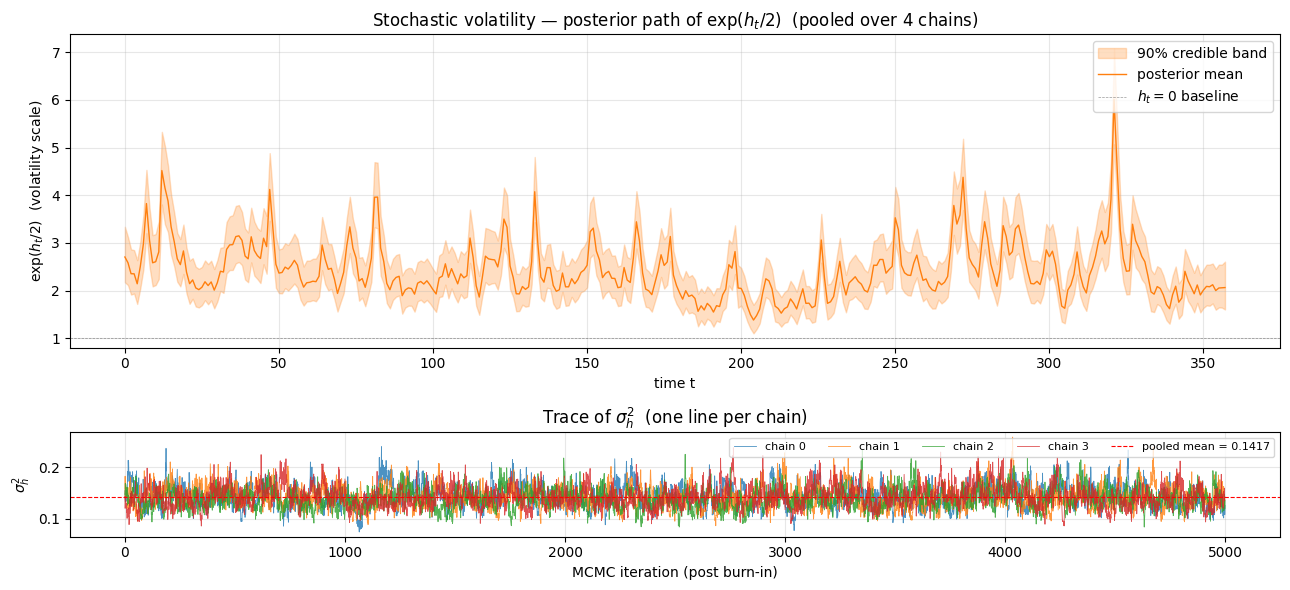

In [12]:
# --------------------------------------------------------------
# Config
# --------------------------------------------------------------
LOW_PCT  = 5
HIGH_PCT = 95


# --------------------------------------------------------------
# Pull h from the stacked dict and pool across chains
# --------------------------------------------------------------
# stacked['h'] has shape (N_CHAINS, T_eff, N_KEEP)
h_stacked = stacked['h']
n_chains, T_eff, N_KEEP = h_stacked.shape
print(f"[load] h: n_chains={n_chains}, T_eff={T_eff}, N_KEEP={N_KEEP}")

# Pool chains: reshape (n_chains, T_eff, N_KEEP) -> (T_eff, n_chains * N_KEEP).
# We swap the chain axis to the back, then merge it with N_KEEP.
h_pool = h_stacked.transpose(1, 0, 2).reshape(T_eff, n_chains * N_KEEP)
print(f"[pool] h_pool: shape={h_pool.shape}  (pooled draws per time point)")


# --------------------------------------------------------------
# Transform every draw to the scale, THEN summarise
# --------------------------------------------------------------
scale      = np.exp(0.5 * h_pool)          # (T_eff, n_chains * N_KEEP)
scale_mean = scale.mean(axis=1)
scale_lo   = np.percentile(scale, LOW_PCT,  axis=1)
scale_hi   = np.percentile(scale, HIGH_PCT, axis=1)

print(f"[diag] scale mean: min={scale_mean.min():.3f}  max={scale_mean.max():.3f}")
print(f"[diag] avg credible band width = {(scale_hi - scale_lo).mean():.3f}")
print(f"[diag] ratio max/min of scale_mean = {scale_mean.max() / scale_mean.min():.2f}x")


# --------------------------------------------------------------
# sigma_h^2 trace, one line per chain (using `scalars`)
# --------------------------------------------------------------
# scalars['sigma_h2'] has shape (N_CHAINS, N_KEEP)
sigma_traces = scalars.get('sigma_h2', None)


# --------------------------------------------------------------
# Plot
# --------------------------------------------------------------
if sigma_traces is not None:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 6),
                                   gridspec_kw={'height_ratios': [3, 1]})
else:
    fig, ax1 = plt.subplots(figsize=(13, 4))

# --- Panel 1: posterior path of exp(h_t / 2) -------------------------
ax1.fill_between(np.arange(T_eff), scale_lo, scale_hi, alpha=0.25,
                 color='C1', label=f"{HIGH_PCT - LOW_PCT}% credible band")
ax1.plot(scale_mean, lw=1.0, color='C1', label="posterior mean")
ax1.axhline(1.0, color='black', lw=0.5, ls='--', alpha=0.4,
            label=r"$h_t = 0$ baseline")
ax1.set_xlabel("time t")
ax1.set_ylabel(r"$\exp(h_t / 2)$  (volatility scale)")
ax1.set_title(rf"Stochastic volatility — posterior path of $\exp(h_t/2)$  "
              rf"(pooled over {n_chains} chains)")
ax1.legend(loc='upper right')
ax1.grid(alpha=0.3)

# --- Panel 2: one sigma_h^2 trace per chain ---------------------------
if sigma_traces is not None:
    for c in range(n_chains):
        ax2.plot(sigma_traces[c], lw=0.6, alpha=0.8, label=f"chain {c}")
    pooled_mean = sigma_traces.mean()
    ax2.axhline(pooled_mean, color='red', lw=0.8, ls='--',
                label=f"pooled mean = {pooled_mean:.4f}")
    ax2.set_xlabel("MCMC iteration (post burn-in)")
    ax2.set_ylabel(r"$\sigma_h^2$")
    ax2.set_title(r"Trace of $\sigma_h^2$  (one line per chain)")
    ax2.legend(loc='upper right', ncol=min(n_chains + 1, 5), fontsize=8)
    ax2.grid(alpha=0.3)

fig.tight_layout()
plt.show()